In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
df = pd.read_csv('../data/heart.csv')

# 🤨 Initial view

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
print(df.duplicated().sum()) #تعداد داده های تکراری

723


In [7]:
df = df.drop_duplicates() #حذف داده های تکراری. 302 رکورد باقیمانده

In [8]:
def save_chart(filename):   #save charts
    figures_dir = Path("../figures")
    figures_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        figures_dir / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

# 🟢 Univariate Analysis

## 1) Age

In [9]:
df['age'].describe()

count    302.00000
mean      54.42053
std        9.04797
min       29.00000
25%       48.00000
50%       55.50000
75%       61.00000
max       77.00000
Name: age, dtype: float64

In [10]:
df['age'].skew()

np.float64(-0.20374327959596905)

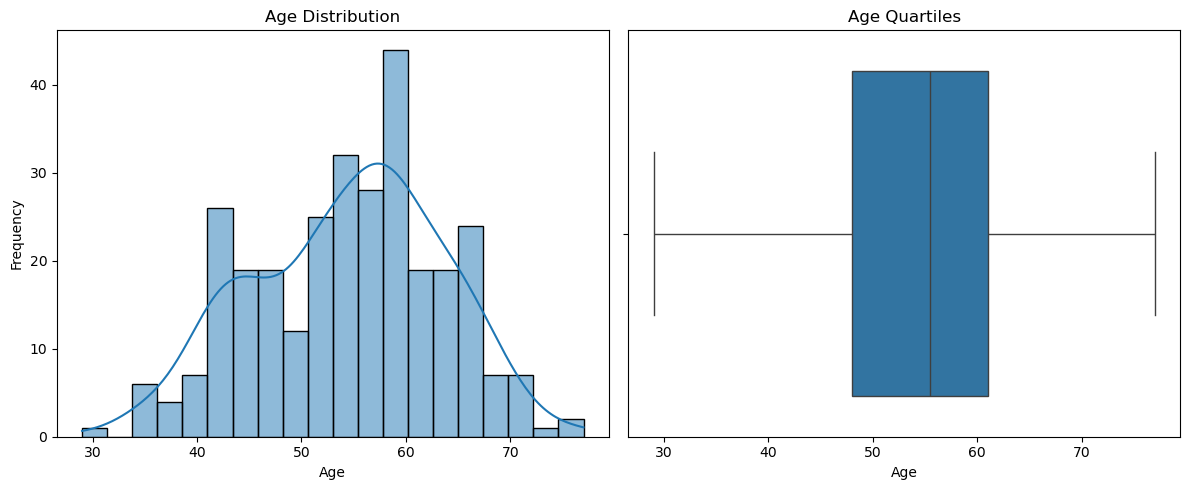

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))   # نمایش دوتا نمودار کنار هم 
sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency") 

sns.boxplot(data=df, x="age", ax=axes[1])
axes[1].set_title("Age Quartiles")
axes[1].set_xlabel("Age")

plt.tight_layout()
save_chart("age_chart")
plt.show()

## 2) Gender

In [12]:
df['sex'].value_counts()

sex
1    206
0     96
Name: count, dtype: int64

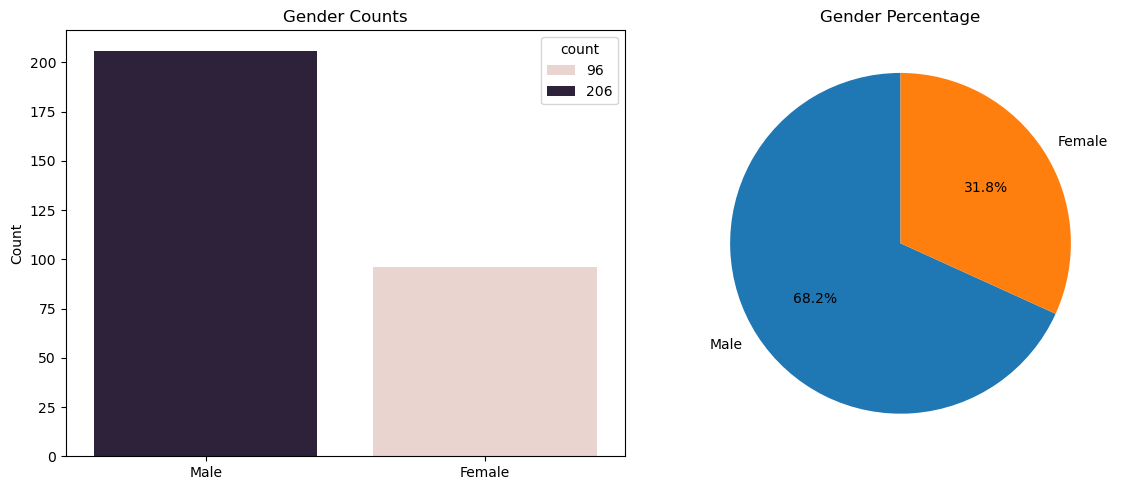

In [13]:
gender_labels = {
    0: "Female",
    1: "Male"
}
counts = df["sex"].value_counts()
labels = [gender_labels[x] for x in counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=labels, y=counts,hue=counts, ax=axes[0])
axes[0].set_title("Gender Counts")
axes[0].set_ylabel("Count")

axes[1].pie(counts, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Gender Percentage")

plt.tight_layout()
save_chart("gender_chart")
plt.show()

## 3) Chest Pain Type

In [14]:
df['cp'].value_counts()

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64

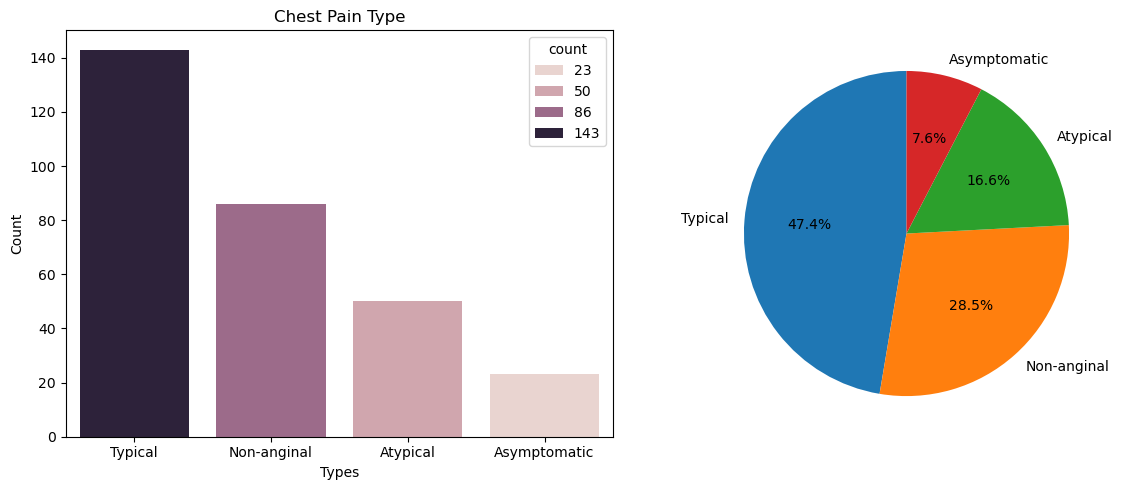

In [15]:
cp_labels = {
    0: "Typical",
    1: "Atypical",
    2: "Non-anginal",
    3: "Asymptomatic"
}
counts = df["cp"].value_counts()
labels = [cp_labels[x] for x in counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=labels, y=counts, hue=counts, ax=axes[0])
axes[0].set_title("Chest Pain Type")
axes[0].set_xlabel("Types")
axes[0].set_ylabel("Count")

axes[1].pie(counts, labels=labels, autopct="%1.1f%%", startangle=90)

plt.tight_layout()
save_chart("cp_chart")
plt.show()

## 4) Resting Blood pressure

In [16]:
df['trestbps'].describe()

count    302.000000
mean     131.602649
std       17.563394
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [17]:
df['trestbps'].skew()

np.float64(0.7165414326647316)

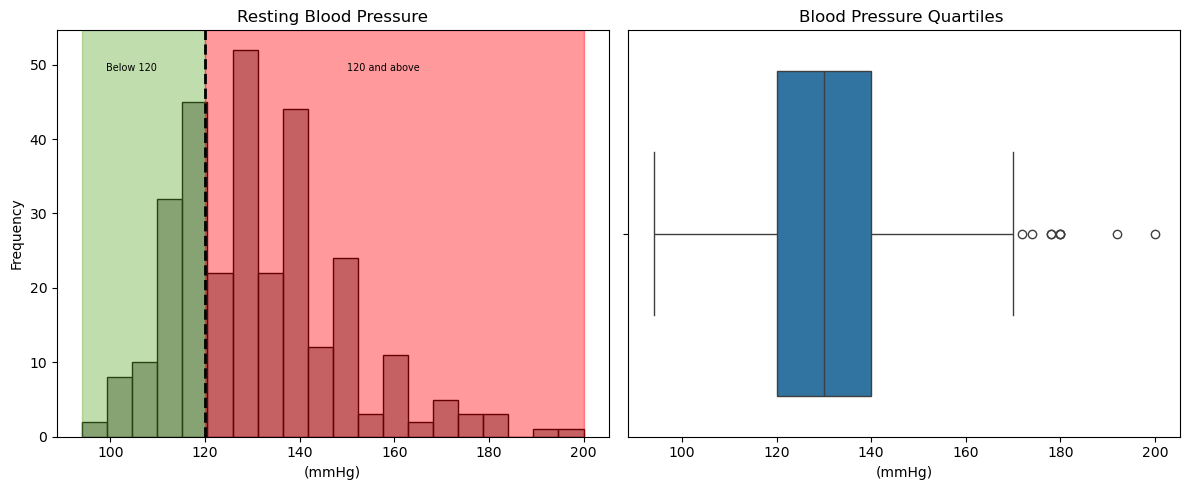

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x="trestbps", color="gray", bins=20, ax=axes[0])
# بازه بندی فشارخون
normal_bp = 120
axes[0].axvline(x=normal_bp, linestyle="--", color="black", linewidth=2)

axes[0].axvspan(df["trestbps"].min(), normal_bp , alpha=0.4, color="#63AA33")
axes[0].text(99, axes[0].get_ylim()[1] * 0.9, "Below 120", fontsize=7)

axes[0].axvspan(normal_bp, df["trestbps"].max(), alpha=0.4, color="#FF0009")
axes[0].text(150, axes[0].get_ylim()[1] * 0.9, "120 and above", fontsize=7)

axes[0].set_title("Resting Blood Pressure")
axes[0].set_xlabel("(mmHg)")
axes[0].set_ylabel("Frequency") 

#باکس پلات 
sns.boxplot(data=df, x="trestbps", ax=axes[1])
axes[1].set_title("Blood Pressure Quartiles ")
axes[1].set_xlabel("(mmHg)")

plt.tight_layout()
save_chart("trestbpd_chart")
plt.show()

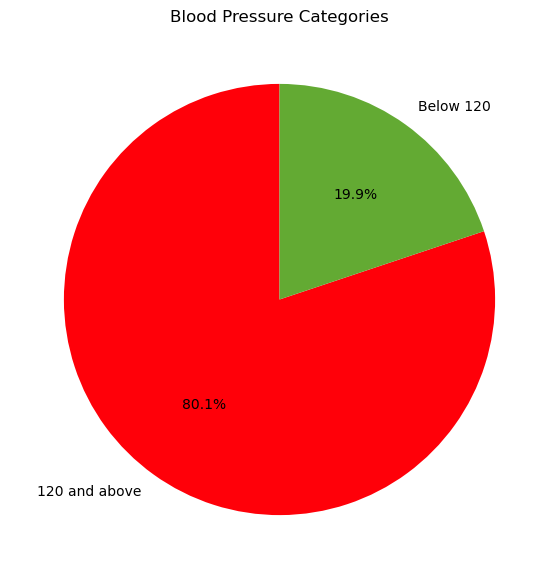

In [19]:
def categorize_blood_pressure(x):
    if 0 < x < 120:
        return "Below 120"
    elif 120 <= x:
        return "120 and above"
        
df["BP_Category"] = df["trestbps"].apply(categorize_blood_pressure) # این ماژول یک تابع را روی مقادیر سری اعمال میکند
counts = df["BP_Category"].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#FF0009','#63AA33']
plt.pie(counts, labels=counts.index, colors=colors, autopct="%1.1f%%", startangle=90)

plt.title("Blood Pressure Categories")
save_chart("bps_categories_chart")
plt.show()

## 5) Serum cholesterol

In [20]:
df['chol'].describe()

count    302.000000
mean     246.500000
std       51.753489
min      126.000000
25%      211.000000
50%      240.500000
75%      274.750000
max      564.000000
Name: chol, dtype: float64

In [21]:
df['chol'].skew()

np.float64(1.147332413980798)

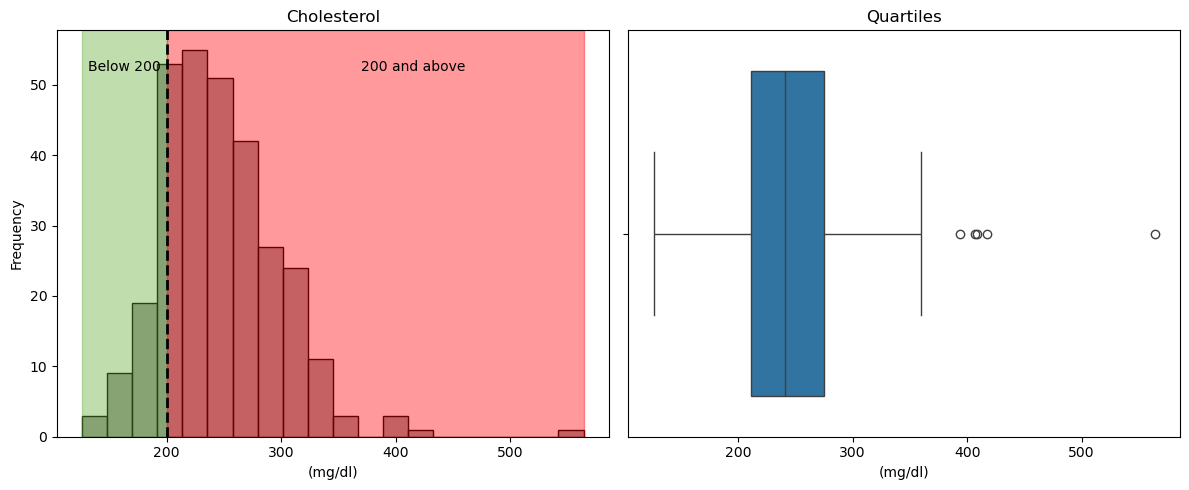

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x="chol", color='gray', bins=20, ax=axes[0])
# بازه بندی میزان کلسترول خون
normal_chol = 200
axes[0].axvline(x=normal_chol, linestyle='--', color='black', linewidth=2)
axes[0].axvspan(df['chol'].min(), normal_chol , alpha=0.4, color='#63AA33')
axes[0].text(131, axes[0].get_ylim()[1] * 0.9, "Below 200", fontsize=10)

axes[0].axvspan(normal_chol, df['chol'].max(), alpha=0.4, color='#FF0009')
axes[0].text(370, axes[0].get_ylim()[1] * 0.9, "200 and above", fontsize=10)


axes[0].set_title("Cholesterol")
axes[0].set_xlabel("(mg/dl)")
axes[0].set_ylabel("Frequency") 


sns.boxplot(data=df, x="chol", ax=axes[1])
axes[1].set_title("Quartiles")
axes[1].set_xlabel("(mg/dl)")

plt.tight_layout()
save_chart('cholesterol_chart')
plt.show()

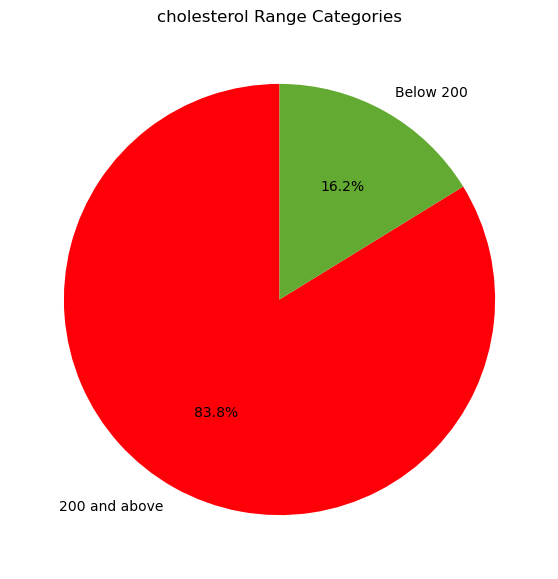

In [23]:
def categorize_cholesterol_range(x):
    if x < 200:
        return "Below 200"
    elif 200 <= x:
        return "200 and above"

df["chol_Category"] = df["chol"].apply(categorize_cholesterol_range)
counts = df["chol_Category"].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#FF0009','#63AA33']
plt.pie(counts, labels=counts.index, colors=colors, autopct="%1.1f%%", startangle=90)

plt.title("cholesterol Range Categories")
save_chart('chol_Categories_chart')
plt.show()

## 6) Exercise Induced Angina

In [24]:
df['exang'].value_counts()

exang
0    203
1     99
Name: count, dtype: int64

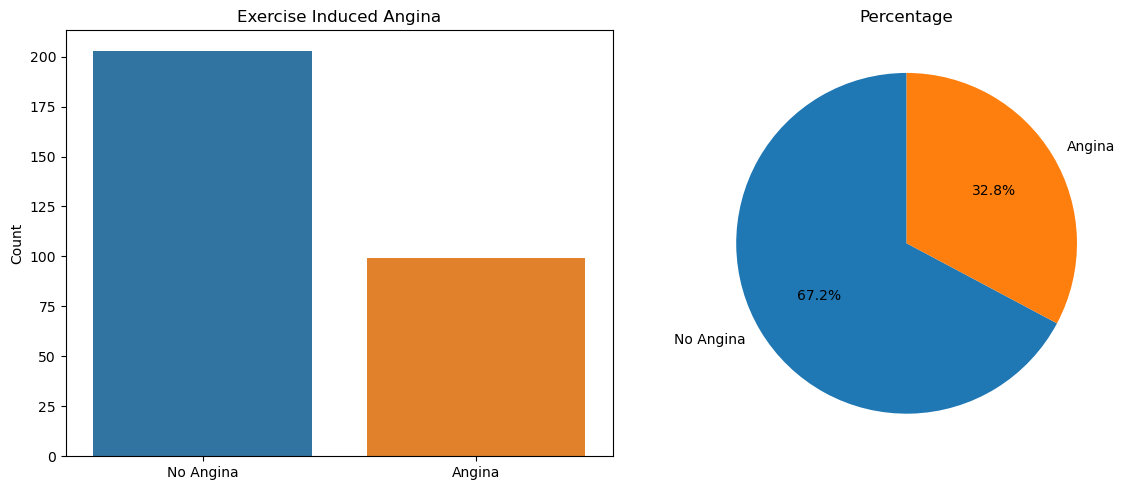

In [25]:
exang_labels = {
    0: "No Angina",
    1: "Angina"
}
counts = df["exang"].value_counts()
labels = [exang_labels[x] for x in counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=labels, y=counts.values, hue=labels, ax=axes[0])
axes[0].set_title("Exercise Induced Angina")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title('Percentage')

plt.tight_layout()
save_chart('exang_chart')
plt.show()

## 7) Target

In [26]:
pct = df['target'].value_counts()/len(df['target']) *100
pct

target
1    54.304636
0    45.695364
Name: count, dtype: float64

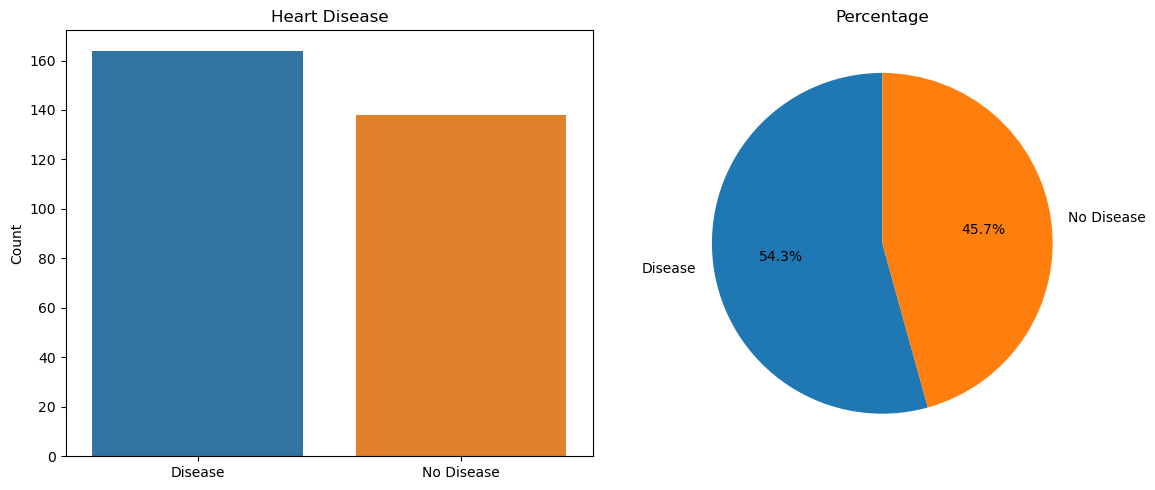

In [27]:
target_labels = {
    0: "No Disease",
    1: "Disease"
}
counts = df["target"].value_counts()
labels = [target_labels[x] for x in counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=labels, y=counts.values, hue=labels, ax=axes[0])
axes[0].set_title("Heart Disease")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title('Percentage')
plt.tight_layout()
save_chart('target_chart')
plt.show()

# ♟ Correlation Analysis

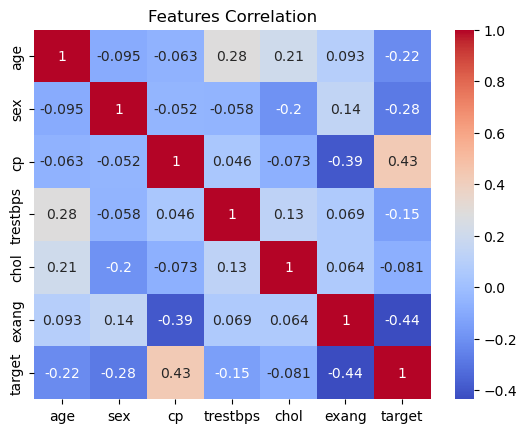

In [28]:
corr_df =  df[['age', 'sex', 'cp', 'trestbps', 'chol', 'exang', 'target']]
corr = corr_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Features Correlation")
save_chart('correlation_heatmap')
plt.show()

In [29]:
corr['target'].sort_values(ascending=False)

target      1.000000
cp          0.432080
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
exang      -0.435601
Name: target, dtype: float64

In [30]:
df['target_label'] = df['target'].map({0: "No Disease", 1: "Disease"}) # اضافه کردن دسته بندی ها برای تحلیل بهتر 
df['sex_label'] = df['sex'].map({0: "Female", 1: "Male"})
df['cp_label'] = df['cp'].map({0: "Typical", 1: "Atypical", 2: "Non-anginal", 3: "Asymptomatic"})

def categorize_blood_pressure(x):
    if 0 < x < 120:
        return "Below 120"
    elif 120 <= x:
        return "120 and above"
        
df["bp_label"] = df["trestbps"].apply(categorize_blood_pressure) 

def categorize_cholesterol_range(x):
    if x < 200:
        return "Below 200"
    elif 200 <= x:
        return "200 and above"

df["chol_label"] = df["chol"].apply(categorize_cholesterol_range)
df['exang_label'] = df['exang'].map({0: "No Angin", 1: "Angin"})

## 1) Age Relation

In [31]:
df.groupby('target')['age'].mean()

target
0    56.601449
1    52.585366
Name: age, dtype: float64

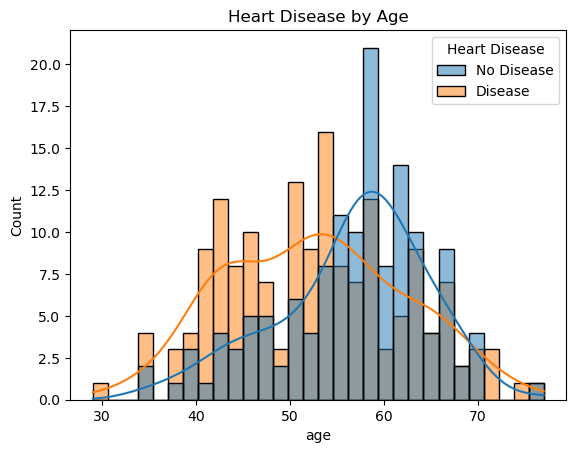

In [32]:
ax = sns.histplot(data=df, x='age', hue='target_label', kde=True, bins=30)
plt.title("Heart Disease by Age")
ax.legend_.set_title(title='Heart Disease')
save_chart('target_by_age')
plt.show()

## 2) Gender Relation

In [33]:
sex_percent = (pd.crosstab(df['sex_label'], df['target_label'], normalize='index').rename_axis(
            index=None, columns=None)).mul(100).round(1)
sex_percent

,Disease,No Disease
Female,75.0,25.0
Male,44.7,55.3


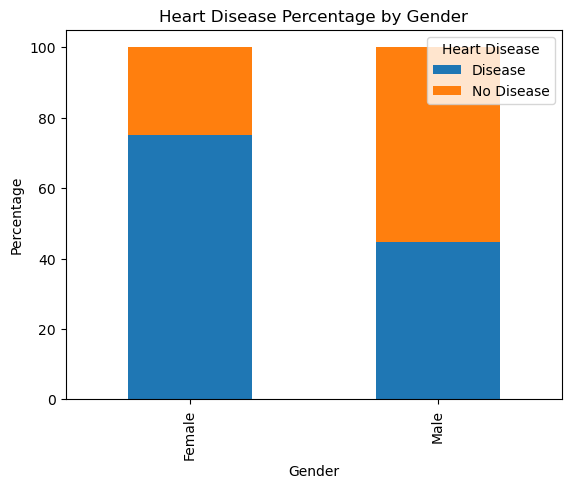

In [34]:
sex_percent.plot(kind='bar', stacked=True)
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Heart Disease Percentage by Gender')
plt.legend(title='Heart Disease')
save_chart('target_by_gender')
plt.show()

## 3) Chest Pain Type Relation

In [35]:
cp_percent = (pd.crosstab(df['cp_label'], df['target_label'], normalize='index').rename_axis(
            index=None, columns=None)).mul(100).round(1)
cp_percent

,Disease,No Disease
Asymptomatic,69.6,30.4
Atypical,82.0,18.0
Non-anginal,79.1,20.9
Typical,27.3,72.7


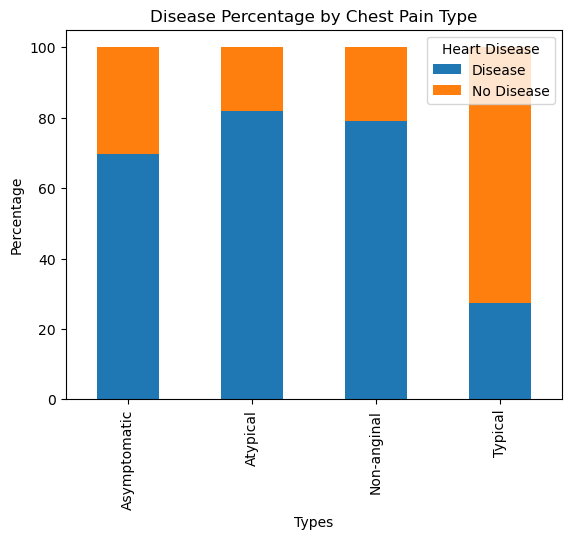

In [36]:
cp_percent.plot(kind='bar', stacked=True)
plt.xlabel('Types')
plt.ylabel('Percentage')
plt.title('Disease Percentage by Chest Pain Type')
plt.legend(title='Heart Disease')
save_chart('target_by_cp')
plt.show()

## 4) Blood Pressure Relation

In [37]:
df.groupby('target')['trestbps'].mean()

target
0    134.398551
1    129.250000
Name: trestbps, dtype: float64

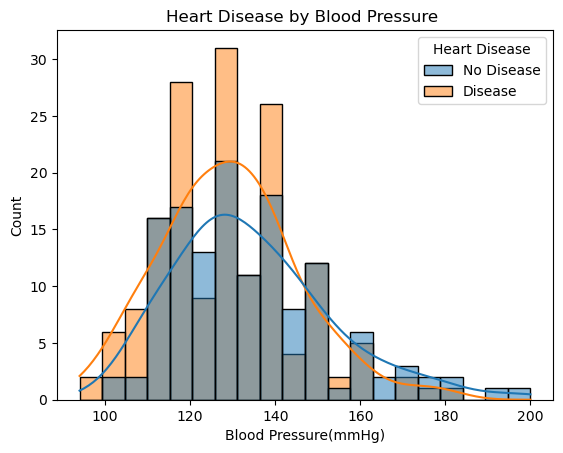

In [38]:
ax = sns.histplot(data=df, x='trestbps', hue='target_label', kde=True, bins=20)
plt.title("Heart Disease by Blood Pressure ")
plt.xlabel('Blood Pressure(mmHg)')
ax.legend_.set_title(title='Heart Disease')
save_chart('target_by_bps')
plt.show()

In [39]:
bp_percent = (pd.crosstab(df['bp_label'], df['target_label'], normalize='index').rename_axis(
            index=None, columns=None)).mul(100).round(1)
bp_percent

,Disease,No Disease
120 and above,52.5,47.5
Below 120,61.7,38.3


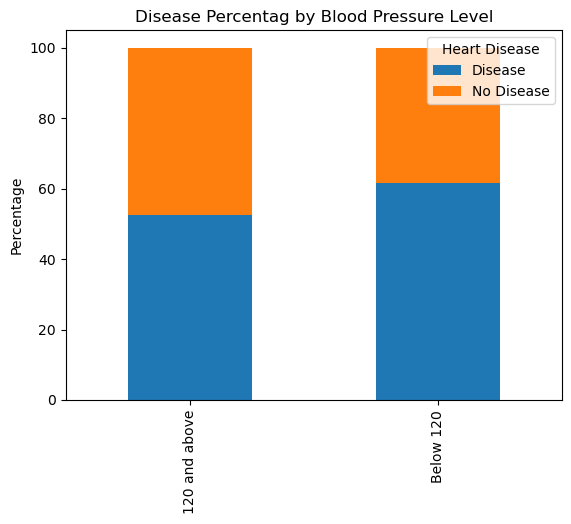

In [40]:
bp_percent.plot(kind='bar', stacked=True)
plt.ylabel('Percentage')
plt.title('Disease Percentag by Blood Pressure Level')
plt.legend(title='Heart Disease')
save_chart('targetcount_by_bps')
plt.show()

## 5) Serum cholesterol Relation

In [41]:
df.groupby('target')['chol'].mean()

target
0    251.086957
1    242.640244
Name: chol, dtype: float64

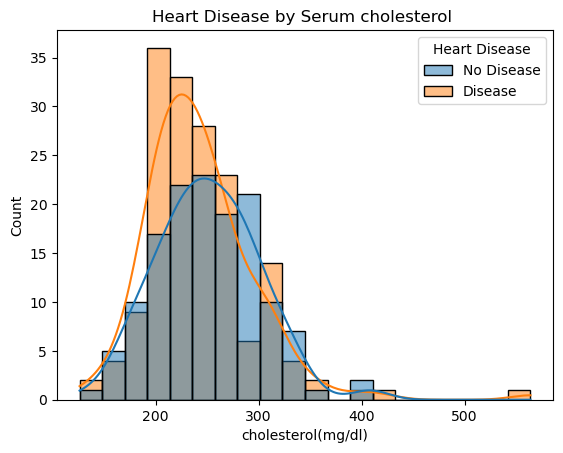

In [42]:
ax = sns.histplot(data=df, x='chol', hue='target_label', kde=True, bins=20)
plt.title("Heart Disease by Serum cholesterol ")
plt.xlabel('cholesterol(mg/dl)')
ax.legend_.set_title(title='Heart Disease')
save_chart('target_by_chol')
plt.show()

In [43]:
chol_percent = (pd.crosstab(df['chol_label'], df['target_label'], normalize='index').rename_axis(
            index=None, columns=None)).mul(100).round(1)
chol_percent

,Disease,No Disease
200 and above,53.4,46.6
Below 200,59.2,40.8


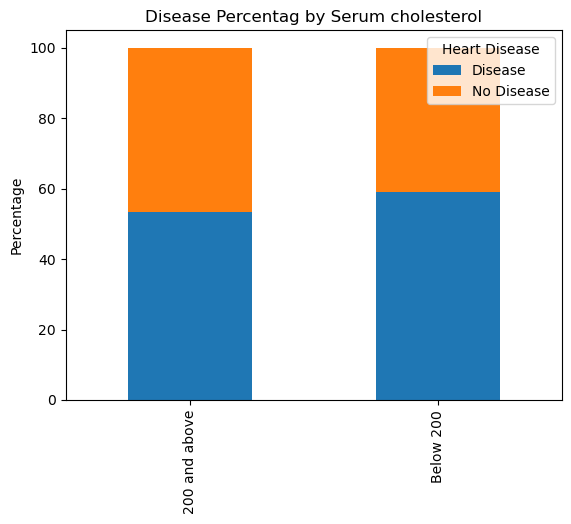

In [44]:
chol_percent.plot(kind='bar', stacked=True)
plt.ylabel('Percentage')
plt.title('Disease Percentag by Serum cholesterol')
plt.legend(title='Heart Disease')
save_chart('targetcount_by_chol')
plt.show()

## 6) Exercise Induced Angina Relation

In [45]:
exang_percent = (pd.crosstab(df['exang_label'], df['target_label'], normalize='index').rename_axis(
            index=None, columns=None)).mul(100).round(1)
exang_percent

,Disease,No Disease
Angin,23.2,76.8
No Angin,69.5,30.5


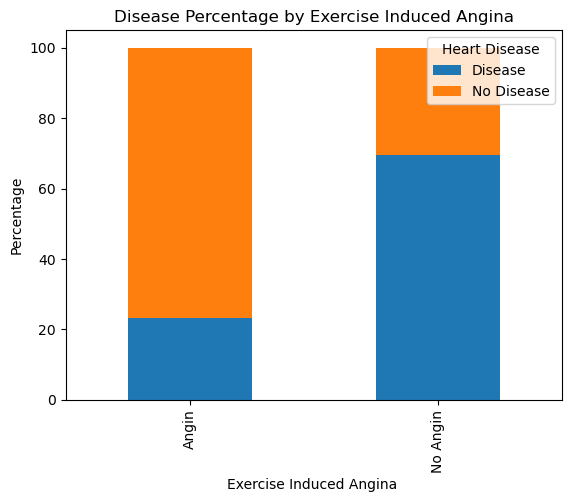

In [46]:
exang_percent.plot(kind='bar', stacked=True)
plt.xlabel('Exercise Induced Angina ')
plt.ylabel('Percentage')
plt.title('Disease Percentage by Exercise Induced Angina')
plt.legend(title='Heart Disease')
save_chart('target_by_exang')
plt.show()

# 💠 Composition of Relation

## 1) Age and Gender

In [47]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,45,65,100],
    labels=['<45','45-65','65+'])

In [48]:
age_sex_data = df.groupby(['sex_label','age_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack().rename_axis(index=None, columns=None)
age_sex_data

,<45,45-65,65+
Female,94.4,66.2,92.3
Male,66.7,40.4,25.0


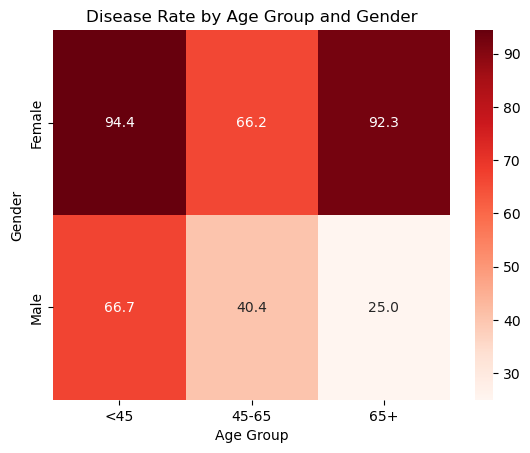

In [49]:
sns.heatmap(
    age_sex_data,
    annot=True,
    cmap="Reds",
    fmt='.1f'
)

plt.xlabel("Age Group")
plt.ylabel("Gender")
plt.title("Disease Rate by Age Group and Gender")
save_chart('age_gender')
plt.show()

## 2) Age and Chest Pain Type

In [50]:
age_cp_data = df.groupby(['cp_label','age_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack().rename_axis(index=None, columns=None)
age_cp_data

,<45,45-65,65+
Asymptomatic,60.0,66.7,100.0
Atypical,100.0,73.3,75.0
Non-anginal,100.0,75.0,63.6
Typical,39.1,24.8,26.7


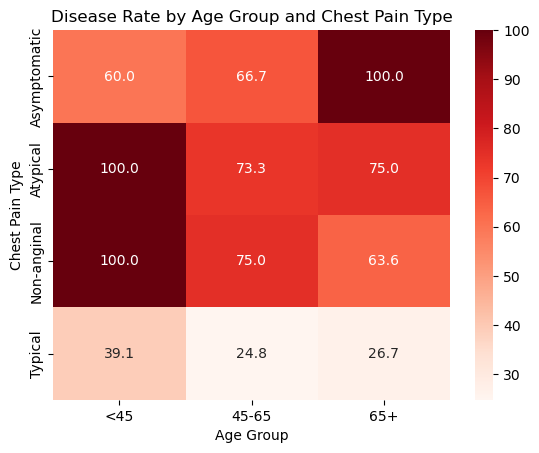

In [51]:
sns.heatmap(
    age_cp_data,
    annot=True,
    cmap="Reds",
    fmt='.1f')

plt.xlabel("Age Group")
plt.ylabel("Chest Pain Type")
plt.title("Disease Rate by Age Group and Chest Pain Type")
save_chart('age_cp')
plt.show()

## 3) Gender and Chest Pain Type

In [52]:
sex_cp_data = pd.crosstab(
                df["cp_label"],
                df["sex_label"],
                values=df["target"],
                aggfunc="mean").mul(100).round(1).rename_axis(index=None, columns=None)
sex_cp_data

,Female,Male
Asymptomatic,100.0,63.2
Atypical,88.9,78.1
Non-anginal,97.1,66.7
Typical,46.2,20.2


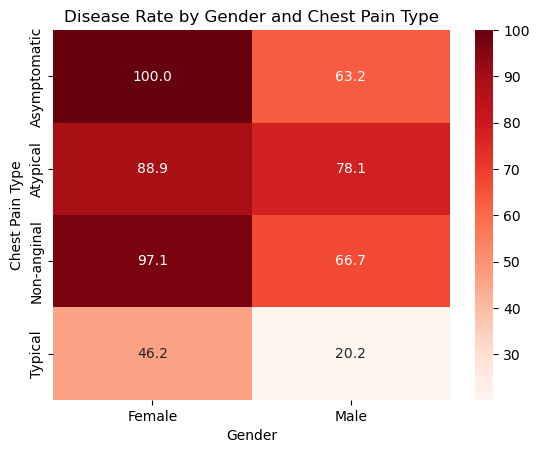

In [53]:
sns.heatmap(
    sex_cp_data,
    annot=True,
    cmap="Reds",
    fmt='.1f')

plt.xlabel("Gender")
plt.ylabel("Chest Pain Type")
plt.title("Disease Rate by Gender and Chest Pain Type")
save_chart('gender_cp')
plt.show()

## 4) Gender and Exercise Induced Angina

In [54]:
sex_exang_data = pd.crosstab(
                df["sex_label"],
                df["exang_label"],
                values=df["target"],
                aggfunc="mean").mul(100).round(1).rename_axis(index=None, columns=None)
sex_exang_data

,Angin,No Angin
Female,36.4,86.5
Male,19.5,59.7


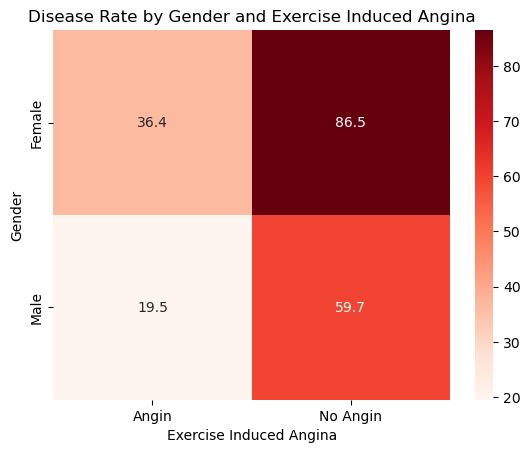

In [55]:
sns.heatmap(
    sex_exang_data,
    annot=True,
    cmap="Reds",
    fmt='.1f')

plt.xlabel("Exercise Induced Angina")
plt.ylabel("Gender")
plt.title("Disease Rate by Gender and Exercise Induced Angina")
save_chart('gender_exang')
plt.show()

## 5) Chest Pain Type and Exercise Induced Angina

In [56]:
cp_exang_data = pd.crosstab(
                df["cp_label"],
                df["exang_label"],
                values=df["target"],
                aggfunc="mean").mul(100).round(1).rename_axis(index=None, columns=None)
cp_exang_data

,Angin,No Angin
Asymptomatic,75.0,68.4
Atypical,75.0,82.6
Non-anginal,63.6,81.3
Typical,12.5,46.0


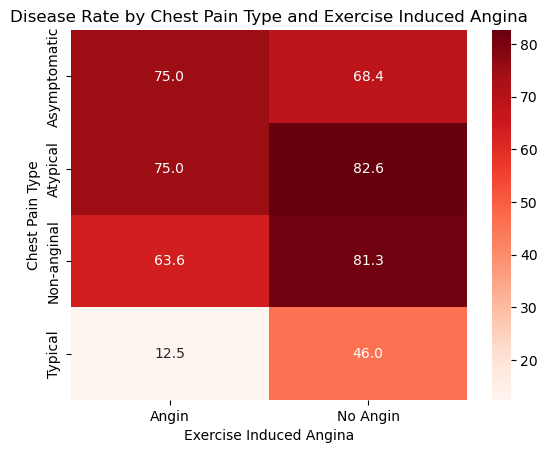

In [57]:
sns.heatmap(
    cp_exang_data,
    annot=True,
    cmap="Reds",
    fmt='.1f')

plt.xlabel("Exercise Induced Angina")
plt.ylabel("Chest Pain Type")
plt.title("Disease Rate by Chest Pain Type and Exercise Induced Angina")
save_chart('cp_exang')
plt.show()

## 6) Age and Exercise Induced Angina

In [58]:
age_exang_data = df.groupby(['exang_label','age_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack().rename_axis(index=None, columns=None)
age_exang_data

,<45,45-65,65+
Angin,33.3,23.3,9.1
No Angin,87.5,62.4,72.7


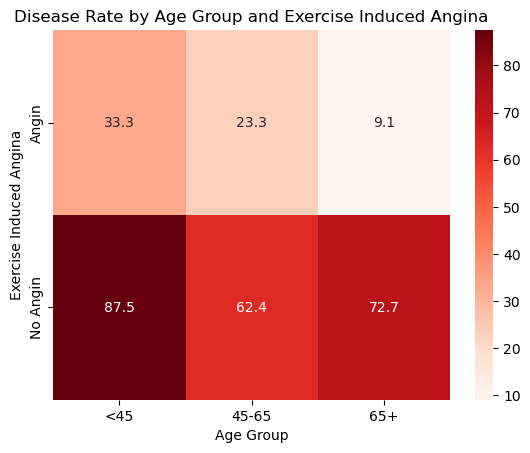

In [59]:
sns.heatmap(
    age_exang_data,
    annot=True,
    cmap="Reds",
    fmt='.1f'
)

plt.xlabel("Age Group")
plt.ylabel("Exercise Induced Angina")
plt.title("Disease Rate by Age Group and Exercise Induced Angina")
save_chart('age_exang')
plt.show()

## 7) Age and Serum cholesterol

In [60]:
df['chol_group'] = pd.cut(
    df['chol'],
    bins=[0,200,600],
    labels=['Below 200','200 and above'])

In [61]:
age_chol_data = df.groupby(['chol_group','age_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack().rename_axis(index=None, columns=None)
age_chol_data

,<45,45-65,65+
Below 200,64.7,55.2,50.0
200 and above,78.3,47.5,51.7


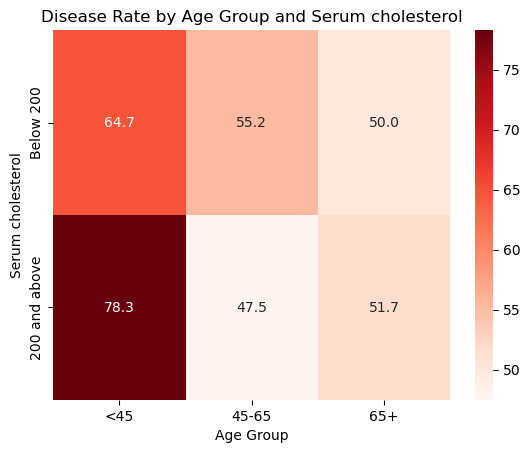

In [62]:
sns.heatmap(
    age_chol_data,
    annot=True,
    cmap="Reds",
    fmt='.1f'
)

plt.xlabel("Age Group")
plt.ylabel("Serum cholesterol")
plt.title("Disease Rate by Age Group and Serum cholesterol")
save_chart('age_chol_heatmap')
plt.show()

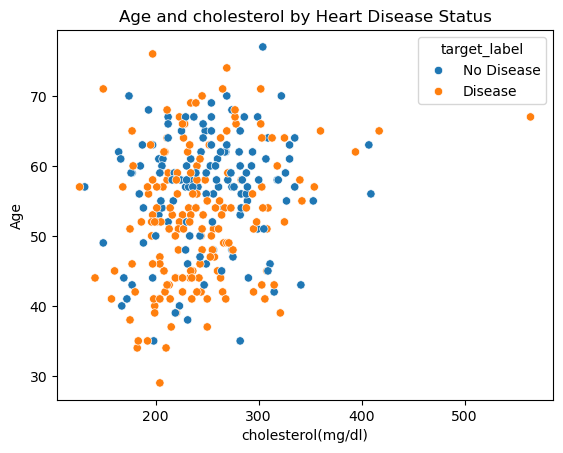

In [63]:
sns.scatterplot(
    data=df,
    x='chol',
    y='age',
    hue='target_label' 
)
plt.xlabel("cholesterol(mg/dl)")
plt.ylabel("Age")
plt.title("Age and cholesterol by Heart Disease Status")
save_chart('age_chol_scatter')
plt.show()

## 8) Age and Blood Pressure 

In [64]:
df['bp_group'] = pd.cut(
    df['trestbps'],
    bins=[0,120,300],
    labels=['Below 120','120 and above'])

In [65]:
age_bp_data = df.groupby(['bp_group','age_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack().rename_axis(index=None, columns=None)
age_bp_data

,<45,45-65,65+
Below 120,69.7,55.8,66.7
120 and above,80.0,46.1,42.9


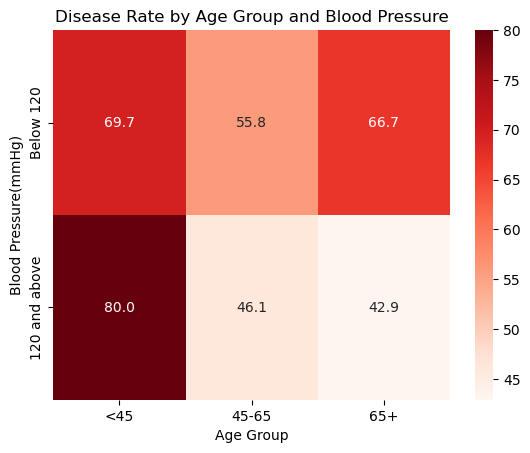

In [66]:
sns.heatmap(
    age_bp_data,
    annot=True,
    cmap="Reds",
    fmt='.1f'
)

plt.xlabel("Age Group")
plt.ylabel("Blood Pressure(mmHg)")
plt.title("Disease Rate by Age Group and Blood Pressure")
save_chart('age_bps_heatmap')
plt.show()

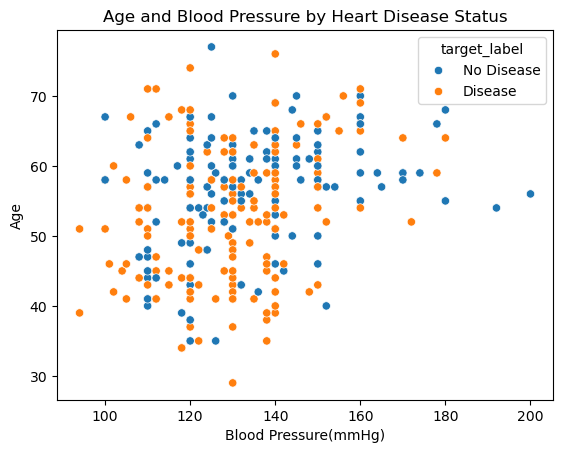

In [67]:
sns.scatterplot(
    data=df,
    x='trestbps',
    y='age',
    hue='target_label' 
)
plt.xlabel("Blood Pressure(mmHg)")
plt.ylabel("Age")
plt.title("Age and Blood Pressure by Heart Disease Status")
save_chart('age_bps_scatter')
plt.show()

## 9) Blood Pressure and Serum cholesterol

In [68]:
chol_bp_data = df.groupby(['bp_group','chol_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack().rename_axis(index=None, columns=None)
chol_bp_data

,Below 200,200 and above
Below 120,59.1,62.7
120 and above,57.1,49.7


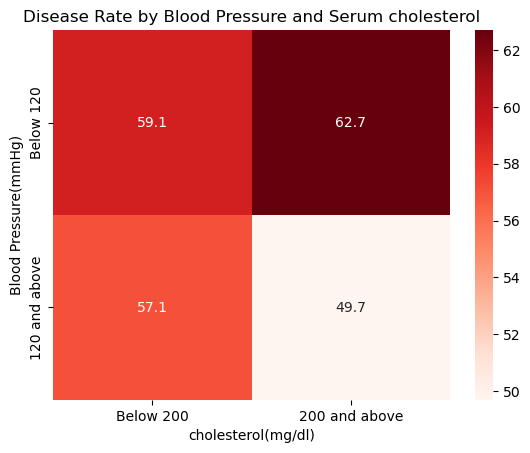

In [69]:
sns.heatmap(
    chol_bp_data,
    annot=True,
    cmap="Reds",
    fmt='.1f'
)

plt.xlabel("cholesterol(mg/dl)")
plt.ylabel("Blood Pressure(mmHg)")
plt.title("Disease Rate by Blood Pressure and Serum cholesterol")
save_chart('bps_chol_heatmap')
plt.show()

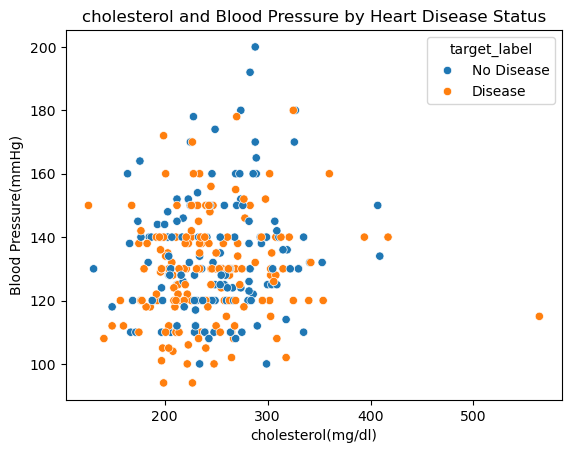

In [70]:
sns.scatterplot(
    data=df,
    x='chol',
    y='trestbps',
    hue='target_label' 
)
plt.xlabel("cholesterol(mg/dl)")
plt.ylabel("Blood Pressure(mmHg)")
plt.title("cholesterol and Blood Pressure by Heart Disease Status")
save_chart('bps_chol_scatter')
plt.show()

## 10) Age, Gender and Chest Pain Type

In [71]:
ac_pivot_famales = pd.pivot_table(
    df[df['sex'] == 0],
    values='target',
    index='age_group',
    columns='cp_label',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

ac_pivot_males = pd.pivot_table(
    df[df['sex'] == 1],
    values='target',
    index='age_group',
    columns='cp_label',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

print(f'{ac_pivot_famales}\n\n')
print(ac_pivot_males)

cp_label   Asymptomatic  Atypical  Non-anginal  Typical
age_group                                              
<45                 NaN     100.0        100.0     75.0
45-65             100.0      80.0         95.2     40.6
65+               100.0     100.0        100.0     66.7


cp_label   Asymptomatic  Atypical  Non-anginal  Typical
age_group                                              
<45                60.0     100.0        100.0     31.6
45-65              61.5      70.0         62.9     17.8
65+               100.0      50.0         20.0     16.7


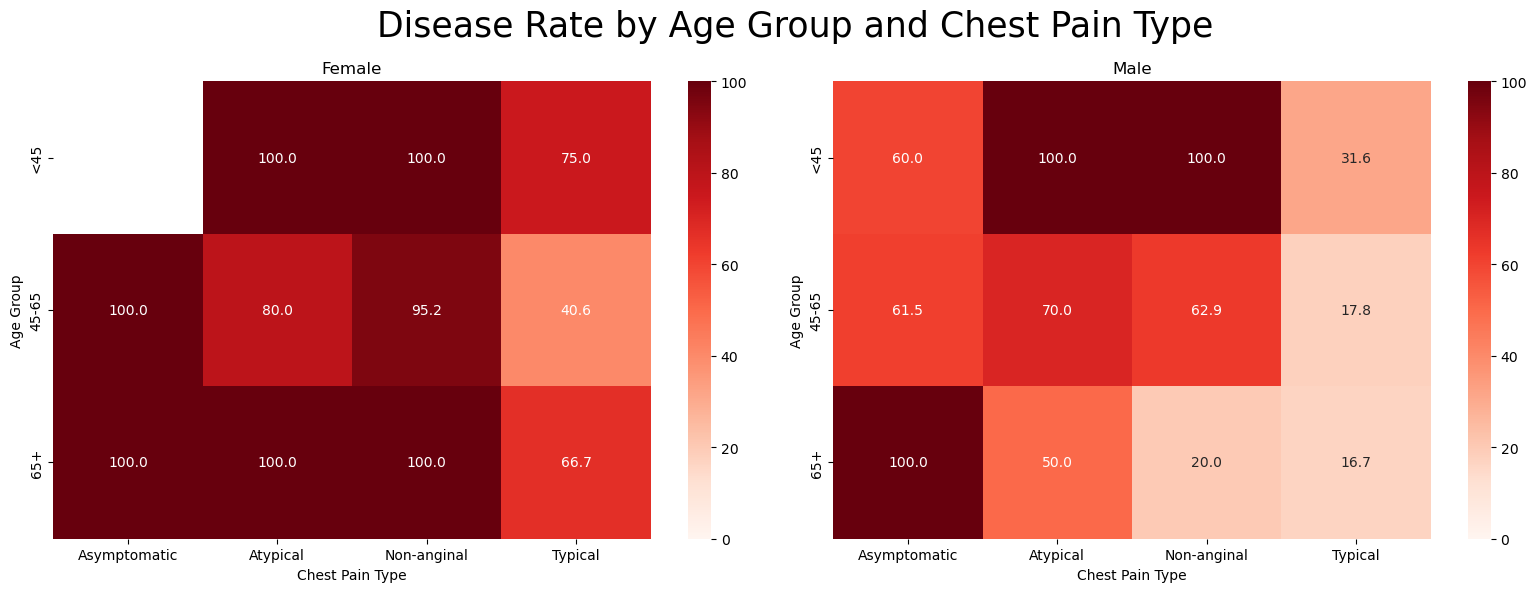

In [72]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

#Females
sns.heatmap(
    ac_pivot_famales,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[0]
)
axes[0].set_title('Female')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Age Group')

#Males
sns.heatmap(
    ac_pivot_males,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].set_title('Male')
axes[1].set_xlabel('Chest Pain Type')
axes[1].set_ylabel('Age Group')

plt.suptitle('Disease Rate by Age Group and Chest Pain Type', fontsize=25)

plt.tight_layout()
save_chart('age_gender_cp')
plt.show()

> NaN values in the following cross-tabulations indicate
> combinations with no observations in the dataset.

## 11) Age, Chest Pain Type and Exercise Induced Angina

In [73]:
ac_pivot_nopain = pd.pivot_table(
    df[df['exang'] == 0],
    values='target',
    index='age_group',
    columns='cp_label',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

ac_pivot_pain = pd.pivot_table(
    df[df['exang'] == 1],
    values='target',
    index='age_group',
    columns='cp_label',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

print(f'{ac_pivot_nopain}\n\n')
print(ac_pivot_pain)

cp_label   Asymptomatic  Atypical  Non-anginal  Typical
age_group                                              
<45                66.7     100.0        100.0     58.3
45-65              61.5      71.4         75.5     41.9
65+               100.0     100.0         77.8     50.0


cp_label   Asymptomatic  Atypical  Non-anginal  Typical
age_group                                              
<45                50.0       NaN        100.0     18.2
45-65             100.0     100.0         71.4     12.9
65+                 NaN      50.0          0.0      0.0


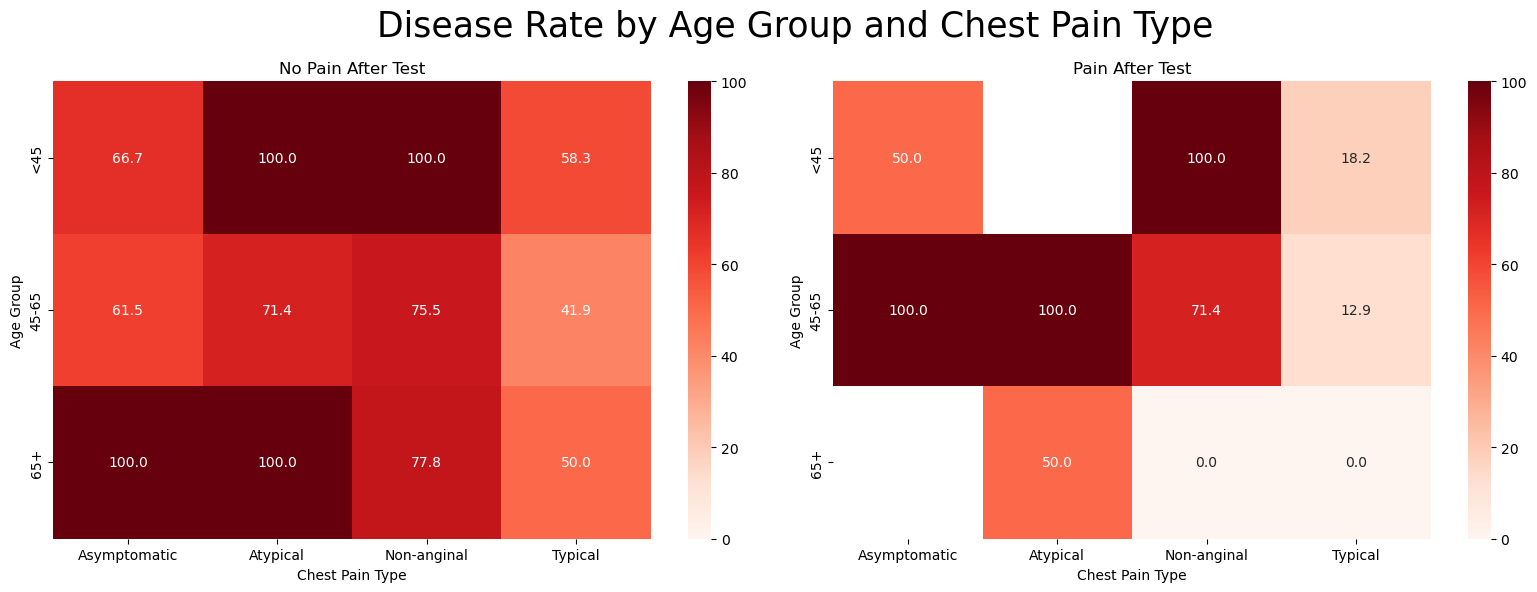

In [74]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

#nopain
sns.heatmap(
    ac_pivot_nopain,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[0]
)
axes[0].set_title('No Pain After Test')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Age Group')

#pain
sns.heatmap(
    ac_pivot_pain,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].set_title('Pain After Test')
axes[1].set_xlabel('Chest Pain Type')
axes[1].set_ylabel('Age Group')

plt.suptitle('Disease Rate by Age Group and Chest Pain Type', fontsize=25)

plt.tight_layout()
save_chart('age_cp_exang')
plt.show()

> NaN values in the following cross-tabulations indicate
> combinations with no observations in the dataset.

## 12) Gender, Chest Pain Type and Exercise Induced Angina

In [75]:
ec_pivot_female = pd.pivot_table(
    df[df['sex'] == 0],
    values='target',
    index='exang_label',
    columns='cp_label',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

ec_pivot_male = pd.pivot_table(
    df[df['sex'] == 1],
    values='target',
    index='exang_label',
    columns='cp_label',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

print(f'{ec_pivot_female}\n\n')
print(ec_pivot_male)

cp_label     Asymptomatic  Atypical  Non-anginal  Typical
exang_label                                              
Angin                 NaN     100.0        100.0     22.2
No Angin            100.0      87.5         97.0     66.7


cp_label     Asymptomatic  Atypical  Non-anginal  Typical
exang_label                                              
Angin                75.0      50.0         55.6      9.7
No Angin             60.0      80.0         69.0     35.7


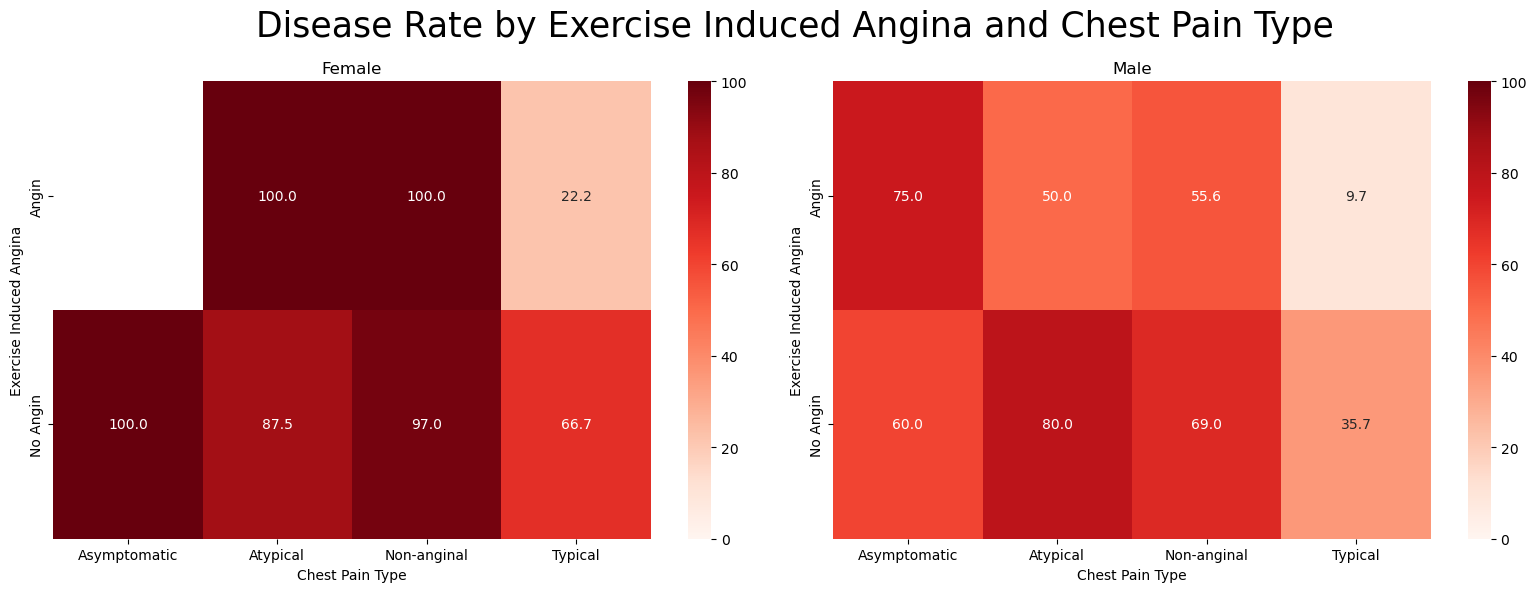

In [76]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

#Females
sns.heatmap(
    ec_pivot_female,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[0]
)
axes[0].set_title('Female')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Exercise Induced Angina')

#Males
sns.heatmap(
    ec_pivot_male,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].set_title('Male')
axes[1].set_xlabel('Chest Pain Type')
axes[1].set_ylabel('Exercise Induced Angina')

plt.suptitle('Disease Rate by Exercise Induced Angina and Chest Pain Type', fontsize=25)

plt.tight_layout()
save_chart('gender_cp_exang')
plt.show()

> NaN values in the following cross-tabulations indicate
> combinations with no observations in the dataset.

## 13) Gender, Age Group and Exercise Induced Angina

In [77]:
ea_pivot_female = pd.pivot_table(
    df[df['sex'] == 0],
    values='target',
    index='exang_label',
    columns='age_group',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

ea_pivot_male = pd.pivot_table(
    df[df['sex'] == 1],
    values='target',
    index='exang_label',
    columns='age_group',
    aggfunc='mean',
    observed=False
).mul(100).round(1)

print(f'{ea_pivot_female}\n\n')
print(ea_pivot_male)

age_group      <45  45-65    65+
exang_label                     
Angin         66.7   29.4   50.0
No Angin     100.0   79.2  100.0


age_group     <45  45-65   65+
exang_label                   
Angin        25.0   21.4   0.0
No Angin     81.8   52.9  45.5


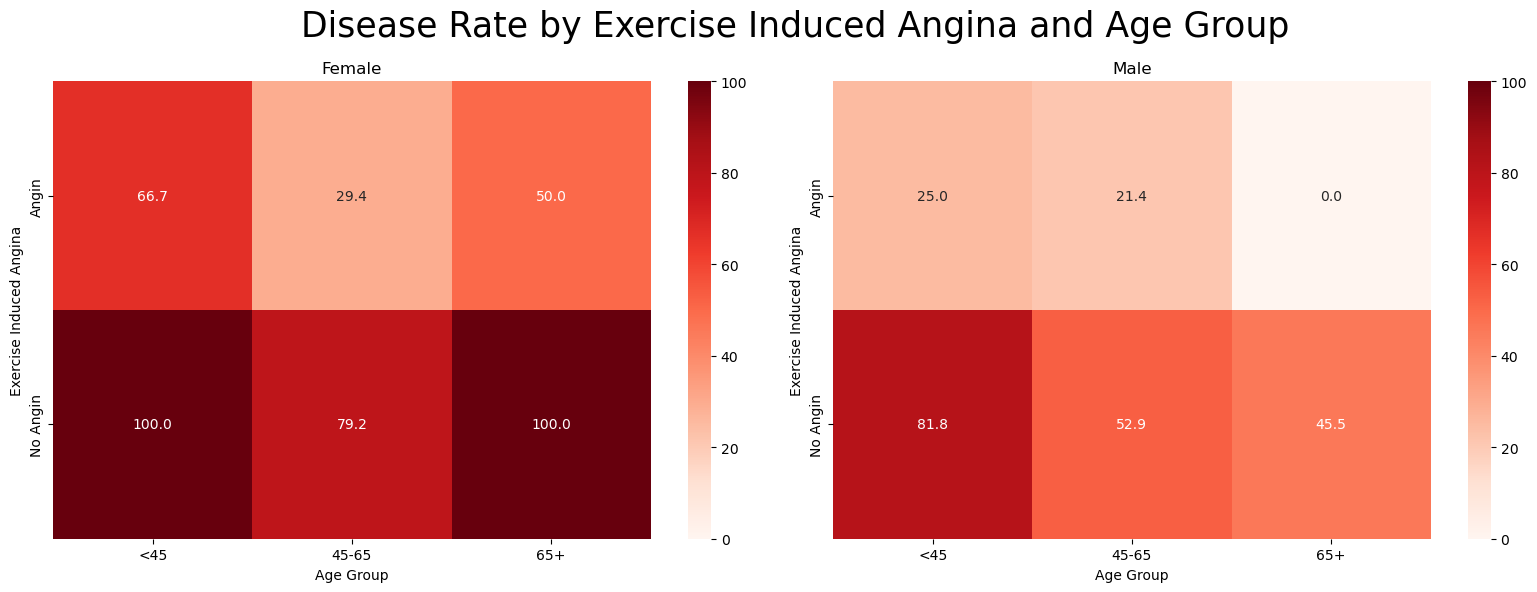

In [78]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

#Females
sns.heatmap(
    ea_pivot_female,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[0]
)
axes[0].set_title('Female')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Exercise Induced Angina')

#Males
sns.heatmap(
    ea_pivot_male,
    annot=True,
    cmap="Reds",
    fmt='.1f',
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].set_title('Male')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Exercise Induced Angina')

plt.suptitle('Disease Rate by Exercise Induced Angina and Age Group', fontsize=25)

plt.tight_layout()
save_chart('gender_age_exang')
plt.show()

## 14) Age Group, Blood Pressure and Serum cholesterol

In [79]:
abc_data = df.groupby(['age_group','bp_group','chol_group'],
           observed=False)['target'].mean().mul(100).round(1).unstack()
abc_data

chol_group               Below 200  200 and above
age_group bp_group                               
<45       Below 120           50.0           81.0
          120 and above      100.0           76.0
45-65     Below 120           66.7           53.5
          120 and above       50.0           45.5
65+       Below 120          100.0           63.6
          120 and above       33.3           44.4

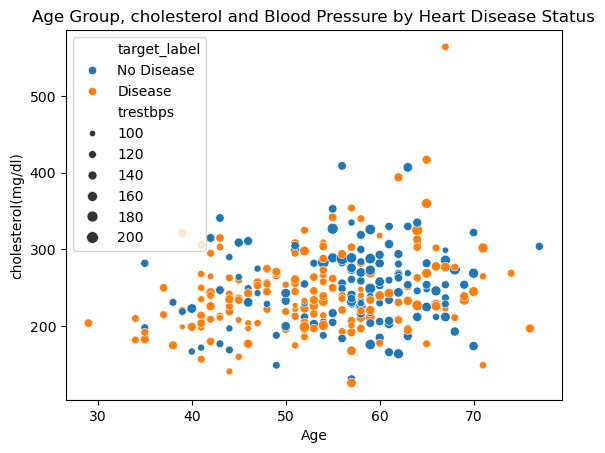

In [80]:
sns.scatterplot(
    data=df,
    x='age',
    y='chol',
    hue='target_label',
    size='trestbps'
)
plt.xlabel("Age")
plt.ylabel("cholesterol(mg/dl)")
plt.title("Age Group, cholesterol and Blood Pressure by Heart Disease Status")
save_chart('age_bps_chol')
plt.show()